In [8]:
# Install required packages (if needed)
# !pip3 install pandas numpy matplotlib seaborn scikit-learn tqdm requests -q

In [9]:
# Ollama API setup and imports
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json
import time
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score, confusion_matrix, classification_report
import numpy as np

print("✓ Libraries imported successfully")
print("✓ Ollama will be used for LLM inference (local)")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Ollama API configuration
OLLAMA_API_URL = "http://localhost:11434/api/generate"

✓ Libraries imported successfully
✓ Ollama will be used for LLM inference (local)


## 1. Load Dataset

In [10]:
# Load the 100% agreement dataset (highest quality)
data_path = "../../../Startified Data PMP/Processed Data/processed_data.csv"

df = pd.read_csv(data_path)
df.rename(columns={"sentiment": "true_sentiment"}, inplace=True)
df.rename(columns={"sentences": "sentence"}, inplace=True)

print(f"Dataset loaded: {len(df)} sentences")

# Display sample
print("\n" + "=" * 80)
print("Sample sentences:")
print("=" * 80)
display(df.sample(5, random_state=42))

Dataset loaded: 210 sentences

Sample sentences:


,sentence,true_sentiment,word_count,char_length
30,Tallink Silja attributes the significant drop ...,negative,46,267
172,"ADP News - Feb 13 , 2009 - Finnish retailer Ke...",negative,43,207
84,20 October 2010 - Finnish environmental manage...,negative,43,237
199,"Finnair 's Tallinn-based subsidiary , Aero AS ...",negative,31,178
60,MegaFon 's subscriber base increased 16.1 % in...,positive,50,246


## 2. Tree-of-Thought Prompt Design

**Multi-Path Reasoning**:
- Path 1: Consider "positive" hypothesis
- Path 2: Consider "negative" hypothesis  
- Path 3: Consider "neutral" hypothesis
- Evaluation: Score each path's evidence strength
- Selection: Choose the most supported hypothesis

In [11]:
def create_tot_prompt(sentence):
    """
    Creates a Tree-of-Thought prompt with multi-path exploration.
    """
    prompt = f"""You are a financial sentiment analysis expert. Analyze this statement using a tree-of-thought approach.

Financial Statement:
"{sentence}"

TASK: Explore three possible sentiment classifications and select the best one.

---
PATH 1: Hypothesis = POSITIVE
Consider if this statement represents positive news for investors.
- What evidence supports this being positive?
- What evidence contradicts this being positive?
- Confidence score (0-1) for this hypothesis:

PATH 2: Hypothesis = NEGATIVE ⚠️
Consider if this statement represents FINANCIAL DETERIORATION for investors.
Look specifically for: losses, declines, revenue drops, margin compression, layoffs, failed ventures, widening losses, falling sales, cost increases, debt problems.
- What evidence supports this being negative?
- What evidence contradicts this being negative?
- Confidence score (0-1) for this hypothesis:

PATH 3: Hypothesis = NEUTRAL
Consider if this statement has no clear market impact.
- What evidence supports this being neutral?
- What evidence contradicts this being neutral?
- Confidence score (0-1) for this hypothesis:

---
FINAL DECISION:
Based on evaluating all three paths, select the hypothesis with the strongest evidence.
Provide ONLY this JSON format (no markdown, no extra text):
Provide your final answer in this exact JSON format:
{{
    "sentiment": "positive/negative/neutral",
    "confidence": 0.0-1.0,
    "rationale": "Explanation of why this hypothesis was selected over the others",
    "path_scores": {{
        "positive": 0.0-1.0,
        "negative": 0.0-1.0,
        "neutral": 0.0-1.0
    }}
}}
"""
    return prompt


# Test prompt
test_sentence = (
    "The company reported mixed results with revenue up 10% but margins declining."
)
print("=" * 80)
print("TREE-OF-THOUGHT PROMPT EXAMPLE")
print("=" * 80)
print(create_tot_prompt(test_sentence))

TREE-OF-THOUGHT PROMPT EXAMPLE
You are a financial sentiment analysis expert. Analyze this statement using a tree-of-thought approach.

Financial Statement:
"The company reported mixed results with revenue up 10% but margins declining."

TASK: Explore three possible sentiment classifications and select the best one.

---
PATH 1: Hypothesis = POSITIVE
Consider if this statement represents positive news for investors.
- What evidence supports this being positive?
- What evidence contradicts this being positive?
- Confidence score (0-1) for this hypothesis:

PATH 2: Hypothesis = NEGATIVE ⚠️
Consider if this statement represents FINANCIAL DETERIORATION for investors.
Look specifically for: losses, declines, revenue drops, margin compression, layoffs, failed ventures, widening losses, falling sales, cost increases, debt problems.
- What evidence supports this being negative?
- What evidence contradicts this being negative?
- Confidence score (0-1) for this hypothesis:

PATH 3: Hypothesis = 

## 3. Model Inference Functions

In [12]:
def call_ollama(prompt, model_name, temperature=0.0):
    """Call Ollama API for LLM inference"""
    max_retries = 3
    last_error = None
    
    for attempt in range(max_retries):
        try:
            response = requests.post(
                OLLAMA_API_URL,
                json={
                    "model": model_name,
                    "prompt": prompt,
                    "stream": False,
                    "temperature": temperature,
                },
                timeout=150,
            )
            
            if response.status_code == 200:
                result = response.json()
                return result.get("response", "")
            else:
                last_error = f"HTTP {response.status_code}"
                
        except Exception as e:
            last_error = str(e)
            print(f"Attempt {attempt + 1}/{max_retries} failed: {last_error}")
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
                continue
            return None
    
    return None


def parse_response(response_text):
    """Parse JSON with path scores from ToT response"""
    try:
        # Try to extract JSON from response
        if "```json" in response_text:
            json_str = response_text.split("```json")[1].split("```")[0].strip()
        elif "{" in response_text:
            start = response_text.find("{")
            end = response_text.rfind("}") + 1
            json_str = response_text[start:end]
        else:
            json_str = response_text.strip()

        result = json.loads(json_str)
        return result
        
    except Exception as e:
        # Fallback: try to extract sentiment with text matching
        response_lower = response_text.lower() if response_text else ""
        if "positive" in response_lower and "negative" not in response_lower:
            return {
                "sentiment": "positive",
                "confidence": 0.5,
                "rationale": "Parsed from text",
                "path_scores": {},
            }
        elif "negative" in response_lower:
            return {
                "sentiment": "negative",
                "confidence": 0.5,
                "rationale": "Parsed from text",
                "path_scores": {},
            }
        elif "neutral" in response_lower:
            return {
                "sentiment": "neutral",
                "confidence": 0.5,
                "rationale": "Parsed from text",
                "path_scores": {},
            }
        return None


print("✓ Model inference functions defined")

✓ Model inference functions defined


In [13]:
# Test API calls with a sample sentence
test_sentence = df["sentence"].iloc[0]
test_prompt = create_tot_prompt(test_sentence)

print("=" * 80)
print("Testing llama3.1:8b...")
print("=" * 80)
llama3_response = call_ollama(test_prompt, model_name="llama3.1:8b")
if llama3_response:
    print(f"✓ Response received (length: {len(llama3_response)})")
    print(f"Response: {llama3_response[:500]}")
    try:
        parsed = json.loads(llama3_response)
        print(f"✓ Parsed successfully: {parsed}")
    except Exception as e:
        print(f"✗ Failed to parse response as JSON: {e}")
else:
    print("✗ llama3.1:8b call failed - no response received")

Testing llama3.1:8b...
✓ Response received (length: 360)
Response: {
    "sentiment": "positive",
    "confidence": 0.9,
    "rationale": "This statement lists a wide range of Nokia phone models, suggesting that the company has a diverse product portfolio and is likely generating significant revenue from these products.",
    "path_scores": {
        "positive": 0.9,
        "negative": 0.05,
        "neutral": 0.05
    }
}
✓ Parsed successfully: {'sentiment': 'positive', 'confidence': 0.9, 'rationale': 'This statement lists a wide range of Nokia phone models, suggesting that the company has a diverse product portfolio and is likely generating significant revenue from these products.', 'path_scores': {'positive': 0.9, 'negative': 0.05, 'neutral': 0.05}}


In [14]:
print("\n" + "=" * 80)
print("Testing qwen3:8b...")
print("=" * 80)
qwen3_response = call_ollama(test_prompt, model_name="qwen3:8b")
if qwen3_response:
    print(f"✓ Response received (length: {len(qwen3_response)})")
    print(f"Response: {qwen3_response[:500]}")
    parsed = parse_response(qwen3_response)
    if parsed:
        print(f"✓ Parsed successfully: {parsed}")
    else:
        print("✗ Failed to parse response")
else:
    print("✗ qwen3:8b call failed - no response received")


Testing qwen3:8b...
✓ Response received (length: 451)
Response: {
    "sentiment": "neutral",
    "confidence": 0.95,
    "rationale": "The statement is purely informational, listing supported Nokia devices without conveying financial performance, market trends, or investor-relevant outcomes. It lacks any explicit positive or negative financial indicators, making neutrality the most accurate classification.",
    "path_scores": {
        "positive": 0.1,
        "negative": 0.1,
        "neutral": 0.95
    }
}
✓ Parsed successfully: {'sentiment': 'neutral', 'confidence': 0.95, 'rationale': 'The statement is purely informational, listing supported Nokia devices without conveying financial performance, market trends, or investor-relevant outcomes. It lacks any explicit positive or negative financial indicators, making neutrality the most accurate classification.', 'path_scores': {'positive': 0.1, 'negative': 0.1, 'neutral': 0.95}}


In [15]:
print("\n" + "=" * 80)
print("Testing deepseek-r1:8b...")
print("=" * 80)
deepseek_response = call_ollama(test_prompt, model_name="deepseek-r1:8b")
if deepseek_response:
    print(f"✓ Response received (length: {len(deepseek_response)})")
    print(f"Response: {deepseek_response[:500]}")
    parsed = parse_response(deepseek_response)
    if parsed:
        print(f"✓ Parsed successfully: {parsed}")
    else:
        print("✗ Failed to parse response")
else:
    print("✗ deepseek-r1:8b call failed - no response received")


Testing deepseek-r1:8b...
✓ Response received (length: 361)
Response: {
    "sentiment": "neutral",
    "confidence": 0.9,
    "rationale": "The statement is a factual list of supported Nokia phone models with no financial context, sentiment indicators, or market impact, making it the strongest fit for neutral classification.",
    "path_scores": {
        "positive": 0.2,
        "negative": 0.1,
        "neutral": 0.9
    }
}
✓ Parsed successfully: {'sentiment': 'neutral', 'confidence': 0.9, 'rationale': 'The statement is a factual list of supported Nokia phone models with no financial context, sentiment indicators, or market impact, making it the strongest fit for neutral classification.', 'path_scores': {'positive': 0.2, 'negative': 0.1, 'neutral': 0.9}}


## 4. Run Experiments

### E10: Llama3.1:8b (Tree-of-Thought)

In [16]:
# E10: Llama3.1:8b (Tree-of-Thought)
print("Running E10: Llama3.1:8b (Tree-of-Thought)...")
e10_results = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="E10 Progress"):
    prompt = create_tot_prompt(row["sentence"])
    response = call_ollama(prompt, model_name="llama3.1:8b")
    if response:
        parsed = parse_response(response)
        if parsed:
            e10_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": parsed.get("sentiment", "unknown"),
                    "confidence": parsed.get("confidence", 0),
                    "rationale": parsed.get("rationale", ""),
                    "path_scores": str(parsed.get("path_scores", {})),
                    "full_response": response[:700],
                }
            )
        else:
            e10_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": "error",
                    "confidence": 0,
                    "rationale": "Parse error",
                    "path_scores": "{}",
                    "full_response": response[:700] if response else "",
                }
            )
    time.sleep(0.1)

e10_df = pd.DataFrame(e10_results)
print(f"\n✓ E10 completed: {len(e10_df)} predictions")
display(e10_df.head())

Running E10: Llama3.1:8b (Tree-of-Thought)...


E10 Progress: 100%|██████████| 210/210 [49:28<00:00, 14.14s/it]


✓ E10 completed: 210 predictions


,sentence,true_sentiment,predicted_sentiment,confidence,rationale,path_scores,full_response
0,"Supported Nokia phones include : N96 , N95-8GB...",neutral,positive,0.9,The statement lists numerous supported Nokia p...,"{'positive': 0.9, 'negative': 0.1, 'neutral': ...","{\n ""sentiment"": ""positive"",\n ""confiden..."
1,Our customers come from the following countrie...,neutral,positive,0.9,The statement lists a diverse range of countri...,"{'positive': 0.9, 'negative': 0.1, 'neutral': ...","{\n ""sentiment"": ""positive"",\n ""confiden..."
2,"Target company : Tieto Corporation , Business ...",neutral,neutral,0.8,The statement provides factual information abo...,"{'positive': 0.2, 'negative': 0.1, 'neutral': ...","{\n ""sentiment"": ""neutral"",\n ""confidenc..."
3,Cablevision Systems Corp. CVC Their Madison Sq...,neutral,positive,0.9,The statement mentions that Cablevision System...,"{'positive': 0.9, 'negative': 0.1, 'neutral': ...","Here's the analysis:\n\n{\n ""sentiment"": ""p..."
4,Panostaja Oyj 's Board also decided at its org...,neutral,positive,0.8,The statement mentions the implementation of a...,"{'positive': 0.8, 'negative': 0.2, 'neutral': ...","{\n ""sentiment"": ""positive"",\n ""confiden..."


In [17]:
print("True vs Predicted Sentiment:")
print(e10_df["true_sentiment"].value_counts())
print(e10_df["predicted_sentiment"].value_counts())

True vs Predicted Sentiment:
true_sentiment
neutral     70
negative    70
positive    70
Name: count, dtype: int64
predicted_sentiment
positive    116
negative     73
neutral      21
Name: count, dtype: int64


### E11: Qwen3:8b (Tree-of-Thought)

In [18]:
# E11: Qwen3:8b (Tree-of-Thought)
print("\nRunning E11: Qwen3:8b (Tree-of-Thought)...")
e11_results = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="E11 Progress"):
    prompt = create_tot_prompt(row["sentence"])
    response = call_ollama(prompt, model_name="qwen3:8b")
    if response:
        parsed = parse_response(response)
        if parsed:
            e11_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": parsed.get("sentiment", "unknown"),
                    "confidence": parsed.get("confidence", 0),
                    "rationale": parsed.get("rationale", ""),
                    "path_scores": str(parsed.get("path_scores", {})),
                    "full_response": response[:700],
                }
            )
        else:
            e11_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": "error",
                    "confidence": 0,
                    "rationale": "Parse error",
                    "path_scores": "{}",
                    "full_response": response[:700] if response else "",
                }
            )
    time.sleep(0.1)

e11_df = pd.DataFrame(e11_results)
print(f"\n✓ E11 completed: {len(e11_df)} predictions")
display(e11_df.head())


Running E11: Qwen3:8b (Tree-of-Thought)...


E11 Progress: 100%|██████████| 210/210 [2:45:40<00:00, 47.34s/it]  


✓ E11 completed: 210 predictions


,sentence,true_sentiment,predicted_sentiment,confidence,rationale,path_scores,full_response
0,"Supported Nokia phones include : N96 , N95-8GB...",neutral,neutral,0.95,"The statement is purely informational, listing...","{'positive': 0.2, 'negative': 0.1, 'neutral': ...","{\n ""sentiment"": ""neutral"",\n ""confidenc..."
1,Our customers come from the following countrie...,neutral,neutral,0.95,"The statement is purely factual, listing custo...","{'positive': 0.1, 'negative': 0.1, 'neutral': ...","{\n ""sentiment"": ""neutral"",\n ""confidenc..."
2,"Target company : Tieto Corporation , Business ...",neutral,neutral,0.95,The statement provides factual information abo...,"{'positive': 0.1, 'negative': 0.05, 'neutral':...","{\n ""sentiment"": ""neutral"",\n ""confidenc..."
3,Cablevision Systems Corp. CVC Their Madison Sq...,neutral,neutral,0.85,The statement provides factual information abo...,"{'positive': 0.6, 'negative': 0.1, 'neutral': ...","{\n ""sentiment"": ""neutral"",\n ""confidenc..."
4,Panostaja Oyj 's Board also decided at its org...,neutral,neutral,0.85,The statement describes an operational decisio...,"{'positive': 0.6, 'negative': 0.2, 'neutral': ...","{\n ""sentiment"": ""neutral"",\n ""confidenc..."


In [19]:
print("True vs Predicted Sentiment:")
print(e11_df["true_sentiment"].value_counts())
print(e11_df["predicted_sentiment"].value_counts())

True vs Predicted Sentiment:
true_sentiment
neutral     70
negative    70
positive    70
Name: count, dtype: int64
predicted_sentiment
positive    76
neutral     70
negative    64
Name: count, dtype: int64


### E12: DeepSeek-R1:8b (Tree-of-Thought)

In [20]:
# E12: DeepSeek-R1:8b (Tree-of-Thought)
print("\nRunning E12: DeepSeek-R1:8b (Tree-of-Thought)...")
e12_results = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="E12 Progress"):
    prompt = create_tot_prompt(row["sentence"])
    response = call_ollama(prompt, model_name="deepseek-r1:8b")
    if response:
        parsed = parse_response(response)
        if parsed:
            e12_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": parsed.get("sentiment", "unknown"),
                    "confidence": parsed.get("confidence", 0),
                    "rationale": parsed.get("rationale", ""),
                    "path_scores": str(parsed.get("path_scores", {})),
                    "full_response": response[:700],
                }
            )
        else:
            e12_results.append(
                {
                    "sentence": row["sentence"],
                    "true_sentiment": row["true_sentiment"],
                    "predicted_sentiment": "error",
                    "confidence": 0,
                    "rationale": "Parse error",
                    "path_scores": "{}",
                    "full_response": response[:700] if response else "",
                }
            )
    time.sleep(0.1)

e12_df = pd.DataFrame(e12_results)
print(f"\n✓ E12 completed: {len(e12_df)} predictions")
display(e12_df.head())


Running E12: DeepSeek-R1:8b (Tree-of-Thought)...


E12 Progress:   2%|▏         | 5/210 [05:12<3:37:13, 63.58s/it]

Attempt 1/3 failed: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=150)


E12 Progress:  17%|█▋        | 36/210 [39:29<2:09:39, 44.71s/it]

Attempt 1/3 failed: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=150)


...

E12 Progress:  91%|█████████▏| 192/210 [4:15:59<27:56, 93.12s/it] 

Attempt 1/3 failed: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=150)


E12 Progress: 100%|██████████| 210/210 [4:37:00<00:00, 79.14s/it] 


✓ E12 completed: 209 predictions


,sentence,true_sentiment,predicted_sentiment,confidence,rationale,path_scores,full_response
0,"Supported Nokia phones include : N96 , N95-8GB...",neutral,neutral,0.90,The statement is a factual list of Nokia phone...,"{'positive': 0.1, 'negative': 0.1, 'neutral': ...","```json\n{\n ""sentiment"": ""neutral"",\n ""..."
1,Our customers come from the following countrie...,neutral,neutral,0.85,The statement is a factual list of customer co...,"{'positive': 0.3, 'negative': 0.1, 'neutral': ...","{\n ""sentiment"": ""neutral"",\n ""confidenc..."
2,"Target company : Tieto Corporation , Business ...",neutral,neutral,0.90,The statement provides factual information abo...,"{'positive': 0.1, 'negative': 0.1, 'neutral': ...","```json\n{\n ""sentiment"": ""neutral"",\n ""..."
3,Cablevision Systems Corp. CVC Their Madison Sq...,neutral,neutral,0.80,The statement provides factual information abo...,"{'positive': 0.3, 'negative': 0.1, 'neutral': ...","{\n ""sentiment"": ""neutral"",\n ""confidenc..."
4,Panostaja Oyj 's Board also decided at its org...,neutral,neutral,0.85,The statement describes an administrative deci...,"{'positive': 0.35, 'negative': 0.1, 'neutral':...","{\n ""sentiment"": ""neutral"",\n ""confidenc..."


In [21]:
print("True vs Predicted Sentiment:")
print(e12_df["true_sentiment"].value_counts())
print(e12_df["predicted_sentiment"].value_counts())

True vs Predicted Sentiment:
true_sentiment
neutral     70
positive    70
negative    69
Name: count, dtype: int64
predicted_sentiment
neutral     75
negative    67
positive    67
Name: count, dtype: int64


## 5. Calculate Metrics

In [22]:
def calculate_metrics(df, exp_name):
    """Calculate all evaluation metrics"""
    # Check if dataframe is empty or missing required columns
    if df.empty or "predicted_sentiment" not in df.columns:
        print(f"⚠️ Warning: {exp_name} has no valid predictions!")
        return (
            {
                "Experiment": exp_name,
                "Total Samples": 0,
                "Valid Predictions": 0,
                "Accuracy": 0,
                "Macro-F1": 0,
                "Weighted-F1": 0,
                "Macro-Precision": 0,
                "Macro-Recall": 0,
                "MCC": 0,
                "Positive_Precision": 0,
                "Positive_Recall": 0,
                "Positive_F1": 0,
                "Negative_Precision": 0,
                "Negative_Recall": 0,
                "Negative_F1": 0,
                "Neutral_Precision": 0,
                "Neutral_Recall": 0,
                "Neutral_F1": 0,
            },
            np.zeros((3, 3)),
            pd.DataFrame(),
        )

    # Filter out errors
    valid_df = df[
        df["predicted_sentiment"].isin(["positive", "negative", "neutral"])
    ].copy()

    # Check if we have valid predictions
    if valid_df.empty:
        print(f"⚠️ Warning: {exp_name} has no valid predictions after filtering!")
        return (
            {
                "Experiment": exp_name,
                "Total Samples": len(df),
                "Valid Predictions": 0,
                "Accuracy": 0,
                "Macro-F1": 0,
                "Weighted-F1": 0,
                "Macro-Precision": 0,
                "Macro-Recall": 0,
                "MCC": 0,
                "Positive_Precision": 0,
                "Positive_Recall": 0,
                "Positive_F1": 0,
                "Negative_Precision": 0,
                "Negative_Recall": 0,
                "Negative_F1": 0,
                "Neutral_Precision": 0,
                "Neutral_Recall": 0,
                "Neutral_F1": 0,
            },
            np.zeros((3, 3)),
            pd.DataFrame(),
        )

    y_true = valid_df["true_sentiment"]
    y_pred = valid_df["predicted_sentiment"]

    metrics = {
        "Experiment": exp_name,
        "Total Samples": len(df),
        "Valid Predictions": len(valid_df),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro"),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro"),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }

    # Per-class metrics
    labels = ["positive", "negative", "neutral"]
    precision_per_class = precision_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    recall_per_class = recall_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    f1_per_class = f1_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )

    for i, label in enumerate(labels):
        metrics[f"{label.capitalize()}_Precision"] = precision_per_class[i]
        metrics[f"{label.capitalize()}_Recall"] = recall_per_class[i]
        metrics[f"{label.capitalize()}_F1"] = f1_per_class[i]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    return metrics, cm, valid_df


# Calculate metrics for all experiments
e10_metrics, e10_cm, e10_valid = calculate_metrics(e10_df, "E10: Llama3.1:8b (ToT)")
e11_metrics, e11_cm, e11_valid = calculate_metrics(e11_df, "E11: Qwen3:8b (ToT)")
e12_metrics, e12_cm, e12_valid = calculate_metrics(e12_df, "E12: DeepSeek-R1:8b (ToT)")

# Create metrics comparison table
metrics_df = pd.DataFrame([e10_metrics, e11_metrics, e12_metrics])

print("\n" + "=" * 80)
print("TREE-OF-THOUGHT PERFORMANCE COMPARISON")
print("=" * 80)
display(
    metrics_df[
        ["Experiment", "Accuracy", "Macro-F1", "Macro-Precision", "Macro-Recall", "MCC"]
    ].round(4)
)


TREE-OF-THOUGHT PERFORMANCE COMPARISON


,Experiment,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,MCC
0,E10: Llama3.1:8b (ToT),0.7429,0.7083,0.8251,0.7429,0.6678
1,E11: Qwen3:8b (ToT),0.9333,0.9335,0.9360,0.9333,0.9011
2,E12: DeepSeek-R1:8b (ToT),0.9234,0.9241,0.9257,0.9236,0.8857


## 6. Visualize Results

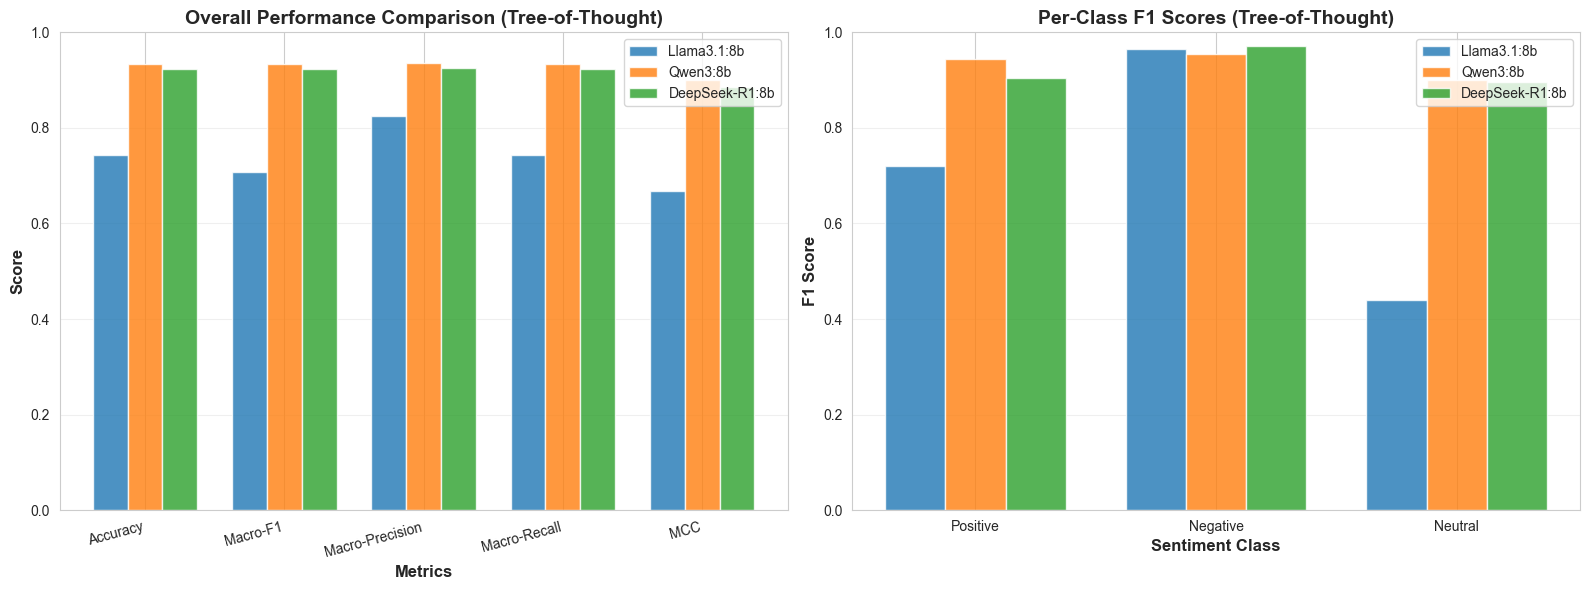

In [23]:
# Performance comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall metrics
metrics_to_plot = ["Accuracy", "Macro-F1", "Macro-Precision", "Macro-Recall", "MCC"]
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (metrics, label) in enumerate(
    [
        (e10_metrics, "Llama3.1:8b"),
        (e11_metrics, "Qwen3:8b"),
        (e12_metrics, "DeepSeek-R1:8b"),
    ]
):
    values = [metrics[m] for m in metrics_to_plot]
    axes[0].bar(x + i * width, values, width, label=label, alpha=0.8)

axes[0].set_xlabel("Metrics", fontsize=12, weight="bold")
axes[0].set_ylabel("Score", fontsize=12, weight="bold")
axes[0].set_title(
    "Overall Performance Comparison (Tree-of-Thought)", fontsize=14, weight="bold"
)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot, rotation=15, ha="right")
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis="y", alpha=0.3)

# Per-class F1 scores
classes = ["Positive", "Negative", "Neutral"]
x2 = np.arange(len(classes))

for i, (metrics, label) in enumerate(
    [
        (e10_metrics, "Llama3.1:8b"),
        (e11_metrics, "Qwen3:8b"),
        (e12_metrics, "DeepSeek-R1:8b"),
    ]
):
    values = [metrics[f"{c}_F1"] for c in classes]
    axes[1].bar(x2 + i * width, values, width, label=label, alpha=0.8)

axes[1].set_xlabel("Sentiment Class", fontsize=12, weight="bold")
axes[1].set_ylabel("F1 Score", fontsize=12, weight="bold")
axes[1].set_title("Per-Class F1 Scores (Tree-of-Thought)", fontsize=14, weight="bold")
axes[1].set_xticks(x2 + width)
axes[1].set_xticklabels(classes)
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("tot_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

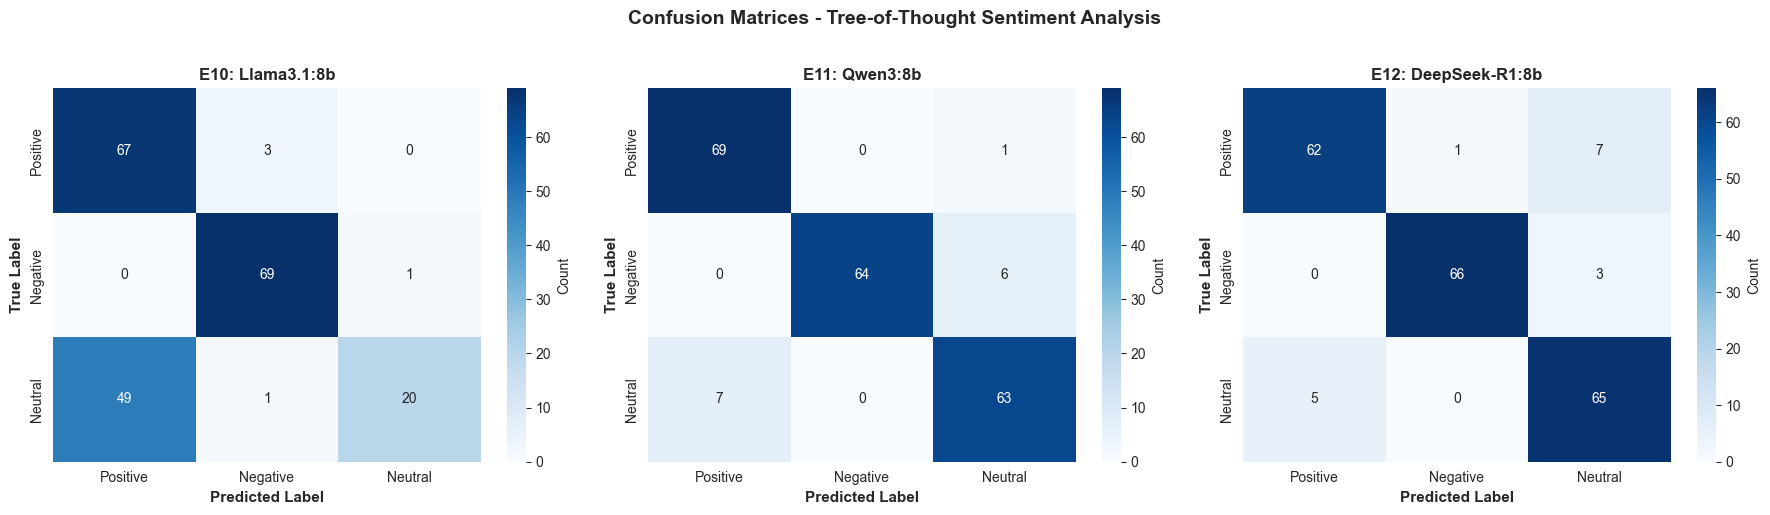

In [24]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Positive", "Negative", "Neutral"]

for idx, (cm, title) in enumerate(
    [
        (e10_cm, "E10: Llama3.1:8b"),
        (e11_cm, "E11: Qwen3:8b"),
        (e12_cm, "E12: DeepSeek-R1:8b"),
    ]
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[idx],
        cbar_kws={"label": "Count"},
    )
    axes[idx].set_title(title, fontsize=12, weight="bold")
    axes[idx].set_ylabel("True Label", fontsize=11, weight="bold")
    axes[idx].set_xlabel("Predicted Label", fontsize=11, weight="bold")

plt.suptitle(
    "Confusion Matrices - Tree-of-Thought Sentiment Analysis",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("tot_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Save Results

In [25]:
# Save detailed results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

e10_df.to_csv(f"e10_llama3.1_8b_tot_{timestamp}.csv", index=False)
e11_df.to_csv(f"e11_qwen3_8b_tot_{timestamp}.csv", index=False)
e12_df.to_csv(f"e12_deepseek_r1_8b_tot_{timestamp}.csv", index=False)
metrics_df.to_csv(f"tot_metrics_summary_{timestamp}.csv", index=False)

print(f"\n✓ Results saved with timestamp: {timestamp}")
print("\nFiles created:")
print(f"  - e10_llama3.1_8b_tot_{timestamp}.csv")
print(f"  - e11_qwen3_8b_tot_{timestamp}.csv")
print(f"  - e12_deepseek_r1_8b_tot_{timestamp}.csv")
print(f"  - tot_metrics_summary_{timestamp}.csv")
print(f"  - tot_performance_comparison.png")
print(f"  - tot_confusion_matrices.png")
print(f"  - tot_confidence_analysis.png")


✓ Results saved with timestamp: 20260223_175903

Files created:
  - e10_llama3.1_8b_tot_20260223_175903.csv
  - e11_qwen3_8b_tot_20260223_175903.csv
  - e12_deepseek_r1_8b_tot_20260223_175903.csv
  - tot_metrics_summary_20260223_175903.csv
  - tot_performance_comparison.png
  - tot_confusion_matrices.png
  - tot_confidence_analysis.png


## 8. Error Analysis

In [26]:
# Error Analysis: Most Common Misclassifications
print("=" * 80)
print("ERROR ANALYSIS: TOP MISCLASSIFIED PATTERNS")
print("=" * 80)

for df_result, exp_name in [
    (e10_valid, "E10: Llama3.1:8b"),
    (e11_valid, "E11: Qwen3:8b"),
    (e12_valid, "E12: DeepSeek-R1:8b"),
]:
    print(f"\n{exp_name}:")
    errors = df_result[df_result["true_sentiment"] != df_result["predicted_sentiment"]]

    # Count confusion pairs
    confusion_pairs = errors.groupby(["true_sentiment", "predicted_sentiment"]).size()
    print(f"Total Errors: {len(errors)}")
    print("\nMost Common Misclassifications:")
    for (true_label, pred_label), count in (
        confusion_pairs.sort_values(ascending=False).head(5).items()
    ):
        print(f"  {true_label} → {pred_label}: {count} errors")

    # Show sample errors
    print(f"\nSample Misclassified Sentences:")
    for idx, row in errors.head(3).iterrows():
        print(f"\n  Sentence: {row['sentence'][:100]}...")
        print(
            f"  True: {row['true_sentiment']} | Predicted: {row['predicted_sentiment']} | Confidence: {row['confidence']:.3f}"
        )

ERROR ANALYSIS: TOP MISCLASSIFIED PATTERNS

E10: Llama3.1:8b:
Total Errors: 54

Most Common Misclassifications:
  neutral → positive: 49 errors
  positive → negative: 3 errors
  negative → neutral: 1 errors
  neutral → negative: 1 errors

Sample Misclassified Sentences:

  Sentence: Supported Nokia phones include : N96 , N95-8GB , N95 , N93-N931 , N92 , N85 , N82 , N81 , N80 , N79 ...
  True: neutral | Predicted: positive | Confidence: 0.900

  Sentence: Our customers come from the following countries : UK , USA , Spain , France , Italy , Germany , Chin...
  True: neutral | Predicted: positive | Confidence: 0.900

  Sentence: Cablevision Systems Corp. CVC Their Madison Square Garden division owns and operates the New York Kn...
  True: neutral | Predicted: positive | Confidence: 0.900

E11: Qwen3:8b:
Total Errors: 14

Most Common Misclassifications:
  neutral → positive: 7 errors
  negative → neutral: 6 errors
  positive → neutral: 1 errors

Sample Misclassified Sentences:

  Sentence:

## 9. Confidence Calibration Analysis

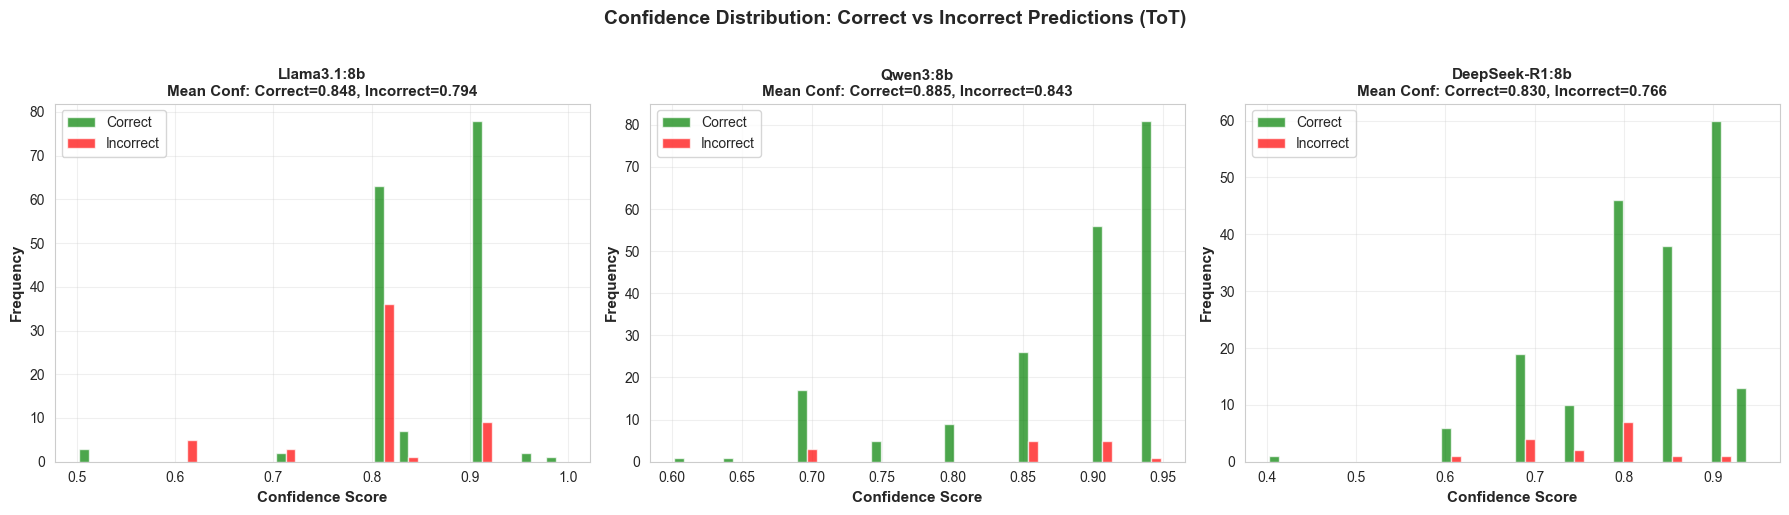

In [27]:
# Confidence analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (df_result, title) in enumerate(
    [(e10_valid, "Llama3.1:8b"), (e11_valid, "Qwen3:8b"), (e12_valid, "DeepSeek-R1:8b")]
):
    df_result["correct"] = (
        df_result["true_sentiment"] == df_result["predicted_sentiment"]
    )

    correct_conf = df_result[df_result["correct"]]["confidence"]
    incorrect_conf = df_result[~df_result["correct"]]["confidence"]

    axes[idx].hist(
        [correct_conf, incorrect_conf],
        bins=20,
        label=["Correct", "Incorrect"],
        alpha=0.7,
        color=["green", "red"],
    )
    axes[idx].set_xlabel("Confidence Score", fontsize=11, weight="bold")
    axes[idx].set_ylabel("Frequency", fontsize=11, weight="bold")
    axes[idx].set_title(
        f"{title}\nMean Conf: Correct={correct_conf.mean():.3f}, Incorrect={incorrect_conf.mean():.3f}",
        fontsize=11,
        weight="bold",
    )
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.suptitle(
    "Confidence Distribution: Correct vs Incorrect Predictions (ToT)",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("tot_confidence_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Classification Reports

In [28]:
# Print detailed metrics for each experiment
print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

for df_result, exp_name in [
    (e10_valid, "E10: Llama3.1:8b (ToT)"),
    (e11_valid, "E11: Qwen3:8b (ToT)"),
    (e12_valid, "E12: DeepSeek-R1:8b (ToT)"),
]:
    print("\n" + "=" * 80)
    print(f"{exp_name}")
    print("=" * 80)
    print(
        classification_report(
            df_result["true_sentiment"],
            df_result["predicted_sentiment"],
            labels=["positive", "negative", "neutral"],
            target_names=["Positive", "Negative", "Neutral"],
        )
    )

# Per-class metrics summary table
print("\n" + "=" * 80)
print("PER-CLASS METRICS SUMMARY")
print("=" * 80)
class_metrics_summary = metrics_df[
    [
        "Experiment",
        "Positive_Precision",
        "Positive_Recall",
        "Positive_F1",
        "Negative_Precision",
        "Negative_Recall",
        "Negative_F1",
        "Neutral_Precision",
        "Neutral_Recall",
        "Neutral_F1",
    ]
]
display(class_metrics_summary.round(4))


DETAILED CLASSIFICATION REPORTS

E10: Llama3.1:8b (ToT)
              precision    recall  f1-score   support

    Positive       0.58      0.96      0.72        70
    Negative       0.95      0.99      0.97        70
     Neutral       0.95      0.29      0.44        70

    accuracy                           0.74       210
   macro avg       0.83      0.74      0.71       210
weighted avg       0.83      0.74      0.71       210


E11: Qwen3:8b (ToT)
              precision    recall  f1-score   support

    Positive       0.91      0.99      0.95        70
    Negative       1.00      0.91      0.96        70
     Neutral       0.90      0.90      0.90        70

    accuracy                           0.93       210
   macro avg       0.94      0.93      0.93       210
weighted avg       0.94      0.93      0.93       210


E12: DeepSeek-R1:8b (ToT)
              precision    recall  f1-score   support

    Positive       0.93      0.89      0.91        70
    Negative       0.99 

,Experiment,Positive_Precision,Positive_Recall,Positive_F1,Negative_Precision,Negative_Recall,Negative_F1,Neutral_Precision,Neutral_Recall,Neutral_F1
0,E10: Llama3.1:8b (ToT),0.5776,0.9571,0.7204,0.9452,0.9857,0.9650,0.9524,0.2857,0.4396
1,E11: Qwen3:8b (ToT),0.9079,0.9857,0.9452,1.0000,0.9143,0.9552,0.9000,0.9000,0.9000
2,E12: DeepSeek-R1:8b (ToT),0.9254,0.8857,0.9051,0.9851,0.9565,0.9706,0.8667,0.9286,0.8966


## 11. Tree-of-Thought vs CoT vs Few-Shot vs Zero-Shot Comparison

In [30]:
# Load results from all prompting approaches for comprehensive comparison
import glob
import os

# Find the most recent results files from each approach
zero_shot_metrics = glob.glob("../Zero_Shot/zero_shot_metrics_summary_*.csv")
few_shot_metrics = glob.glob("../Few_Shot/few_shot_metrics_summary_*.csv")
cot_metrics = glob.glob("../Chain_of_Thought/cot_metrics_summary_*.csv")

all_approaches = []

# Load Zero-Shot results
if zero_shot_metrics:
    zs_df = pd.read_csv(sorted(zero_shot_metrics)[-1])  # Most recent
    zs_df["Approach"] = "Zero-Shot"
    all_approaches.append(zs_df)

# Load Few-Shot results
if few_shot_metrics:
    fs_df = pd.read_csv(sorted(few_shot_metrics)[-1])
    fs_df["Approach"] = "Few-Shot"
    all_approaches.append(fs_df)

# Load CoT results
if cot_metrics:
    cot_df = pd.read_csv(sorted(cot_metrics)[-1])
    cot_df["Approach"] = "Chain-of-Thought"
    all_approaches.append(cot_df)

# Add current ToT results
tot_current = metrics_df.copy()
tot_current["Approach"] = "Tree-of-Thought"
all_approaches.append(tot_current)

# Combine all results
if all_approaches:
    comparison_df = pd.concat(all_approaches, ignore_index=True)

    # Reorder columns for better readability
    cols = [
        'Approach', 'Experiment', 'Total Samples', 'Valid Predictions', 'Accuracy',
       'Macro-F1', 'Weighted-F1', 'Macro-Precision', 'Macro-Recall', 'MCC',
       'Positive_Precision', 'Positive_Recall', 'Positive_F1',
       'Negative_Precision', 'Negative_Recall', 'Negative_F1',
       'Neutral_Precision', 'Neutral_Recall', 'Neutral_F1'
    ]
    available_cols = [c for c in cols if c in comparison_df.columns]

    print("\n" + "=" * 100)
    print("COMPREHENSIVE PROMPTING APPROACH COMPARISON")
    print("=" * 100)
    display(comparison_df[available_cols].round(4))

    # Best performance by approach
    print("\n" + "=" * 100)
    print("BEST PERFORMANCE BY APPROACH")
    print("=" * 100)
    best_by_approach = comparison_df.groupby("Approach")[
        ["Accuracy", "Macro-F1", "MCC"]
    ].max()
    display(best_by_approach.round(4))

    # Analysis
    print("\n" + "=" * 100)
    print("KEY INSIGHTS")
    print("=" * 100)
    best_accuracy_row = comparison_df.loc[comparison_df["Accuracy"].idxmax()]
    best_f1_row = comparison_df.loc[comparison_df["Macro-F1"].idxmax()]
    best_mcc_row = comparison_df.loc[comparison_df["MCC"].idxmax()]

    print(
        f"✓ Best Accuracy: {best_accuracy_row['Experiment']} ({best_accuracy_row['Approach']}) = {best_accuracy_row['Accuracy']:.4f}"
    )
    print(
        f"✓ Best Macro-F1: {best_f1_row['Experiment']} ({best_f1_row['Approach']}) = {best_f1_row['Macro-F1']:.4f}"
    )
    print(
        f"✓ Best MCC: {best_mcc_row['Experiment']} ({best_mcc_row['Approach']}) = {best_mcc_row['MCC']:.4f}"
    )
else:
    print(
        "⚠️ No comparison files found. Run other experiments first to enable full comparison."
    )


COMPREHENSIVE PROMPTING APPROACH COMPARISON


,Approach,Experiment,Total Samples,Valid Predictions,Accuracy,Macro-F1,Weighted-F1,Macro-Precision,Macro-Recall,MCC,Positive_Precision,Positive_Recall,Positive_F1,Negative_Precision,Negative_Recall,Negative_F1,Neutral_Precision,Neutral_Recall,Neutral_F1
0,Zero-Shot,E1: llama3.1:8b,210,210,0.9286,0.9278,0.9278,0.9321,0.9286,0.8952,0.8919,0.9429,0.9167,0.9211,1.0000,0.9589,0.9833,0.8429,0.9077
1,Zero-Shot,E2: qwen3:8b,210,210,0.9524,0.9527,0.9527,0.9538,0.9524,0.9290,0.9706,0.9429,0.9565,0.9853,0.9571,0.9710,0.9054,0.9571,0.9306
2,Zero-Shot,E3: deepseek-r1:8b,210,210,0.9667,0.9668,0.9668,0.9674,0.9667,0.9502,0.9855,0.9714,0.9784,0.9853,0.9571,0.9710,0.9315,0.9714,0.9510
3,Few-Shot,E4: Llama-3.1:8b (Few-Shot),210,210,0.9571,0.9570,0.9570,0.9589,0.9571,NaN,0.9846,0.9143,0.9481,0.9211,1.0000,0.9589,0.9710,0.9571,0.9640
4,Few-Shot,E5: Qwen3:8b (Few-Shot),210,210,0.9524,0.9530,0.9530,0.9583,0.9524,NaN,1.0000,0.9143,0.9552,1.0000,0.9429,0.9706,0.8750,1.0000,0.9333
5,Few-Shot,E6: Deepseek-r1:8b (Few-Shot),210,210,0.9381,0.9382,0.9382,0.9384,0.9381,NaN,0.9143,0.9143,0.9143,0.9855,0.9714,0.9784,0.9155,0.9286,0.9220
6,Chain-of-Thought,E7: Llama3.1:8b (CoT),210,209,0.9091,0.9075,0.9076,0.9154,0.9086,0.8674,0.8667,0.9286,0.8966,0.8974,1.0000,0.9459,0.9821,0.7971,0.8800
7,Chain-of-Thought,E8: Qwen3:8b (CoT),210,210,0.9476,0.9481,0.9481,0.9510,0.9476,0.9227,0.9846,0.9143,0.9481,0.9853,0.9571,0.9710,0.8831,0.9714,0.9252
8,Chain-of-Thought,E9: DeepSeek-R1:8b (CoT),210,210,0.9381,0.9384,0.9384,0.9406,0.9381,0.9081,0.9692,0.9000,0.9333,0.9710,0.9571,0.9640,0.8816,0.9571,0.9178
9,Tree-of-Thought,E10: Llama3.1:8b (ToT),210,210,0.7429,0.7083,0.7083,0.8251,0.7429,0.6678,0.5776,0.9571,0.7204,0.9452,0.9857,0.9650,0.9524,0.2857,0.4396



BEST PERFORMANCE BY APPROACH


,Accuracy,Macro-F1,MCC
Approach,,,
Chain-of-Thought,0.9476,0.9481,0.9227
Few-Shot,0.9571,0.9570,NaN
Tree-of-Thought,0.9333,0.9335,0.9011
Zero-Shot,0.9667,0.9668,0.9502



KEY INSIGHTS
✓ Best Accuracy: E3: deepseek-r1:8b (Zero-Shot) = 0.9667
✓ Best Macro-F1: E3: deepseek-r1:8b (Zero-Shot) = 0.9668
✓ Best MCC: E3: deepseek-r1:8b (Zero-Shot) = 0.9502


In [34]:
#Save comprehensive comparison
if all_approaches:
    comparison_df.to_csv(f"comprehensive_prompting_comparison_{timestamp}.csv", index=False)
    print(f"\n✓ Comprehensive comparison saved: comprehensive_prompting_comparison_{timestamp}.csv")


✓ Comprehensive comparison saved: comprehensive_prompting_comparison_20260223_175903.csv


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
# Load previous approach metrics for comparison
try:
    # Find the most recent metrics files
    zero_shot_files = sorted(glob.glob("../Zero_Shot/zero_shot_metrics_summary_*.csv"))
    few_shot_files = sorted(glob.glob("../Few_Shot/few_shot_metrics_summary_*.csv"))
    cot_files = sorted(glob.glob("../Chain_of_Thought/cot_metrics_summary_*.csv"))
    tot_files = sorted(glob.glob("tot_metrics_summary_*.csv"))

    zero_shot_metrics = pd.read_csv(zero_shot_files[-1]) if zero_shot_files else None
    few_shot_metrics = pd.read_csv(few_shot_files[-1]) if few_shot_files else None
    cot_metrics = pd.read_csv(cot_files[-1]) if cot_files else None
    tot_metrics = pd.read_csv(tot_files[-1]) if tot_files else None

    if zero_shot_metrics is not None:
        print(f"✓ Loaded Zero-Shot metrics from: {zero_shot_files[-1]}")
    if few_shot_metrics is not None:
        print(f"✓ Loaded Few-Shot metrics from: {few_shot_files[-1]}")
    if cot_metrics is not None:
        print(f"✓ Loaded CoT metrics from: {cot_files[-1]}")
    if tot_metrics is not None:
        print(f"✓ Loaded ToT metrics from: {tot_files[-1]}")

except Exception as e:
    print(f"⚠️ Could not load comparison metrics: {e}")
    zero_shot_metrics = None
    few_shot_metrics = None
    cot_metrics = None

✓ Loaded Zero-Shot metrics from: ../Zero_Shot/zero_shot_metrics_summary_20260222_225323.csv
✓ Loaded Few-Shot metrics from: ../Few_Shot/few_shot_metrics_summary_20260223_023100.csv
✓ Loaded CoT metrics from: ../Chain_of_Thought/cot_metrics_summary_20260223_054135.csv
✓ Loaded ToT metrics from: tot_metrics_summary_20260223_175903.csv



CROSS-APPROACH COMPARISON: Zero-Shot vs Few-Shot vs CoT vs ToT


,Approach,Experiment,Total Samples,Valid Predictions,Accuracy,Macro-F1,Weighted-F1,Macro-Precision,Macro-Recall,MCC,Positive_Precision,Positive_Recall,Positive_F1,Negative_Precision,Negative_Recall,Negative_F1,Neutral_Precision,Neutral_Recall,Neutral_F1
0,Zero-Shot,E1: llama3.1:8b,210,210,0.9286,0.9278,0.9278,0.9321,0.9286,0.8952,0.8919,0.9429,0.9167,0.9211,1.0000,0.9589,0.9833,0.8429,0.9077
1,Zero-Shot,E2: qwen3:8b,210,210,0.9524,0.9527,0.9527,0.9538,0.9524,0.9290,0.9706,0.9429,0.9565,0.9853,0.9571,0.9710,0.9054,0.9571,0.9306
2,Zero-Shot,E3: deepseek-r1:8b,210,210,0.9667,0.9668,0.9668,0.9674,0.9667,0.9502,0.9855,0.9714,0.9784,0.9853,0.9571,0.9710,0.9315,0.9714,0.9510
3,Few-Shot,E4: Llama-3.1:8b (Few-Shot),210,210,0.9571,0.9570,0.9570,0.9589,0.9571,NaN,0.9846,0.9143,0.9481,0.9211,1.0000,0.9589,0.9710,0.9571,0.9640
4,Few-Shot,E5: Qwen3:8b (Few-Shot),210,210,0.9524,0.9530,0.9530,0.9583,0.9524,NaN,1.0000,0.9143,0.9552,1.0000,0.9429,0.9706,0.8750,1.0000,0.9333
5,Few-Shot,E6: Deepseek-r1:8b (Few-Shot),210,210,0.9381,0.9382,0.9382,0.9384,0.9381,NaN,0.9143,0.9143,0.9143,0.9855,0.9714,0.9784,0.9155,0.9286,0.9220
6,Chain-of-Thought,E7: Llama3.1:8b (CoT),210,209,0.9091,0.9075,0.9076,0.9154,0.9086,0.8674,0.8667,0.9286,0.8966,0.8974,1.0000,0.9459,0.9821,0.7971,0.8800
7,Chain-of-Thought,E8: Qwen3:8b (CoT),210,210,0.9476,0.9481,0.9481,0.9510,0.9476,0.9227,0.9846,0.9143,0.9481,0.9853,0.9571,0.9710,0.8831,0.9714,0.9252
8,Chain-of-Thought,E9: DeepSeek-R1:8b (CoT),210,210,0.9381,0.9384,0.9384,0.9406,0.9381,0.9081,0.9692,0.9000,0.9333,0.9710,0.9571,0.9640,0.8816,0.9571,0.9178
9,Tree-of-Thought,E10: Llama3.1:8b (ToT),210,210,0.7429,0.7083,0.7083,0.8251,0.7429,0.6678,0.5776,0.9571,0.7204,0.9452,0.9857,0.9650,0.9524,0.2857,0.4396



✓ Full comparison table saved as: all_approaches_comparison_20260226_004917.csv

AVERAGE PERFORMANCE BY APPROACH


,Accuracy,Macro-F1,MCC
Approach,,,
Chain-of-Thought,0.9316,0.9313,0.8994
Few-Shot,0.9492,0.9494,NaN
Tree-of-Thought,0.8665,0.8553,0.8182
Zero-Shot,0.9492,0.9491,0.9248


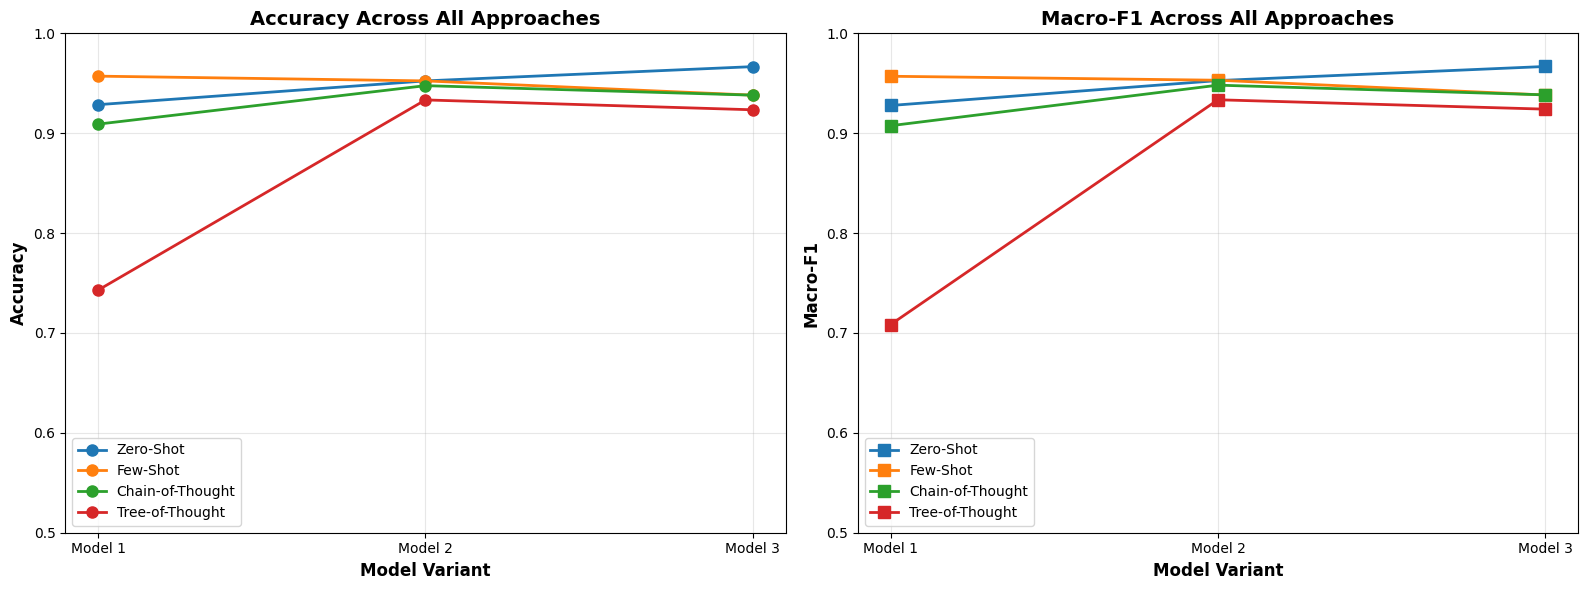

✓ Complete approach comparison visualization saved


In [6]:
#import timestamp
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
metrics_df = tot_metrics if tot_metrics is not None else pd.DataFrame()
# Compare all four approaches
if all(m is not None for m in [zero_shot_metrics, few_shot_metrics, cot_metrics]):
    all_approaches = pd.concat(
        [
            zero_shot_metrics.assign(Approach="Zero-Shot"),
            few_shot_metrics.assign(Approach="Few-Shot"),
            cot_metrics.assign(Approach="Chain-of-Thought"),
            metrics_df.assign(Approach="Tree-of-Thought"),
        ],
        ignore_index=True,
    )

    print("\n" + "=" * 80)
    print("CROSS-APPROACH COMPARISON: Zero-Shot vs Few-Shot vs CoT vs ToT")
    print("=" * 80)

    
    comparison_cols = ["Approach", "Experiment", "Accuracy", "Macro-F1", "MCC"]
    if all(col in all_approaches.columns for col in comparison_cols):
        display(all_approaches[['Approach', 'Experiment', 'Total Samples', 'Valid Predictions', 'Accuracy',
       'Macro-F1', 'Weighted-F1', 'Macro-Precision', 'Macro-Recall', 'MCC',
       'Positive_Precision', 'Positive_Recall', 'Positive_F1',
       'Negative_Precision', 'Negative_Recall', 'Negative_F1',
       'Neutral_Precision', 'Neutral_Recall', 'Neutral_F1']].round(4))
        #save to csv
        all_approaches.to_csv(f"all_approaches_comparison_{timestamp}.csv", index=False)
        print(f"\n✓ Full comparison table saved as: all_approaches_comparison_{timestamp}.csv")
    else:
        display(
            all_approaches[['Approach', 'Experiment', 'Total Samples', 'Valid Predictions', 'Accuracy',
       'Macro-F1', 'Weighted-F1', 'Macro-Precision', 'Macro-Recall', 'MCC',
       'Positive_Precision', 'Positive_Recall', 'Positive_F1',
       'Negative_Precision', 'Negative_Recall', 'Negative_F1',
       'Neutral_Precision', 'Neutral_Recall', 'Neutral_F1' ]].round(4))
       #save to csv
        all_approaches.to_csv(f"all_approaches_comparison_{timestamp}.csv", index=False)
        print(f"\n✓ Full comparison table saved as: all_approaches_comparison_{timestamp}.csv")
        

    print("\n" + "=" * 80)
    print("AVERAGE PERFORMANCE BY APPROACH")
    print("=" * 80)

    approach_avg = all_approaches.groupby("Approach")[["Accuracy", "Macro-F1"]].mean()
    if "MCC" in all_approaches.columns:
        approach_avg["MCC"] = all_approaches.groupby("Approach")["MCC"].mean()

    display(approach_avg.round(4))

    # Visualize approach progression
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for approach in ["Zero-Shot", "Few-Shot", "Chain-of-Thought", "Tree-of-Thought"]:
        approach_data = all_approaches[all_approaches["Approach"] == approach]
        axes[0].plot(
            range(len(approach_data)),
            approach_data["Accuracy"],
            marker="o",
            label=approach,
            linewidth=2,
            markersize=8,
        )

    axes[0].set_xlabel("Model Variant", fontsize=12, weight="bold")
    axes[0].set_ylabel("Accuracy", fontsize=12, weight="bold")
    axes[0].set_title("Accuracy Across All Approaches", fontsize=14, weight="bold")
    axes[0].set_xticks(range(3))
    axes[0].set_xticklabels(["Model 1", "Model 2", "Model 3"])
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim([0.5, 1.0])

    for approach in ["Zero-Shot", "Few-Shot", "Chain-of-Thought", "Tree-of-Thought"]:
        approach_data = all_approaches[all_approaches["Approach"] == approach]
        axes[1].plot(
            range(len(approach_data)),
            approach_data["Macro-F1"],
            marker="s",
            label=approach,
            linewidth=2,
            markersize=8,
        )

    axes[1].set_xlabel("Model Variant", fontsize=12, weight="bold")
    axes[1].set_ylabel("Macro-F1", fontsize=12, weight="bold")
    axes[1].set_title("Macro-F1 Across All Approaches", fontsize=14, weight="bold")
    axes[1].set_xticks(range(3))
    axes[1].set_xticklabels(["Model 1", "Model 2", "Model 3"])
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim([0.5, 1.0])

    plt.tight_layout()
    plt.savefig(
        "all_approaches_comparison_risk_assessment.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

    print("✓ Complete approach comparison visualization saved")
else:
    print("\n⚠️ Cannot perform full comparison - missing baseline metrics")
    print(
        "   Please run Zero-Shot (R1-R3), Few-Shot (R4-R6), and CoT (R7-R9) experiments first"
    )